#  L2-регуляризатор. Математическое обоснование и пример работы

[ 4.91036137e+02  2.42384981e+00 -1.32538113e+00 -1.26409459e+00
 -1.09738011e+00 -1.82853467e-01  6.58132793e-01 -3.03528873e-01
  6.87695561e-02 -8.98123021e-03  6.89772787e-04 -2.90427760e-05
  5.18650488e-07]


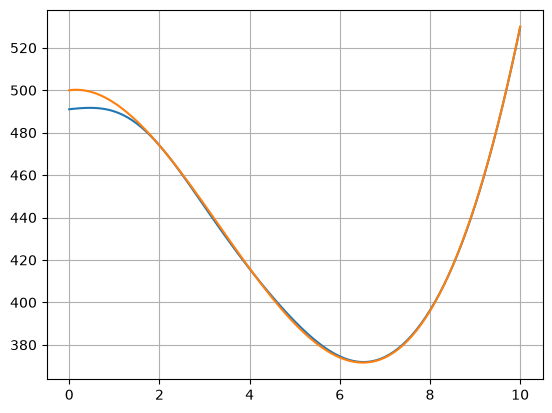

In [2]:
# Пример работы L2-регуляризатора

import numpy as np
import matplotlib.pyplot as plt


x = np.arange(0, 10.1, 0.1)
y = np.array([a ** 3 - 10 * a ** 2 + 3 * a + 500 for a in x])  # функция в виде полинома x^3 - 10x^2 + 3x + 500
x_train, y_train = x[::2], y[::2]
N = 13  # размер признакового пространства (степень полинома N-1)
L = 20  # при увеличении N увеличивается L (кратно): 12; 0.2   13; 20    15; 5000

X = np.array([[a ** n for n in range(N)] for a in x])  # матрица входных векторов
IL = np.array([[L if i == j else 0 for j in range(N)] for i in range(N)])  # матрица lambda*I
IL[0][0] = 0  # первый коэффициент не регуляризуем
X_train = X[::2]  # обучающая выборка
Y = y_train  # обучающая выборка

# вычисление коэффициентов по формуле w = (XT*X + lambda*I)^-1 * XT * Y
A = np.linalg.inv(X_train.T @ X_train + IL)
w = A @ X_train.T @ Y
print(w)

# отображение исходного графика и прогноза
yy = [np.dot(w, x) for x in X]
plt.plot(x, yy)
plt.plot(x, y)
plt.grid(True)
plt.show()

## Задача 1:
Необходимо выполнить аппроксимацию функции:

$f(x)=0.1⋅x+0.1⋅x^2−0.5⋅sin(2x)+cos(4x)+10$

на интервале [-3, 4] моделью вида:

$a(x)=w0+\sum_{i=1}^{N−1}w_i⋅x_i$ при N=22.

В качестве функции потерь следует выбрать квадратическую функцию с L2-регуляризатором:

$L_i(w)+\frac{λ}{2}⋅\tilde{w}^T⋅\tilde{w}$

где $\tilde w=[0,w1,⋯ ,wn]^T$ - вектор с исключенным первым параметром w0. А сами весовые коэффициенты ww вычислить по формуле:

$w^∗=(X^T⋅X+λ⋅I)^{−1}⋅X^T⋅Y$

где $I_{n×n}$​ - единичная матрица размером n×n с первым нулевым значением (I[0,0]=0).

Продолжите программу, в которой задана функция f(x) с именем func, заданы значения функции по оси абсцисс и ординат, а также начальные значения, обучающая выборка X_train, Y_train и параметры для вычисления вектора параметров w∗w∗​:
```python
import numpy as np

def func(x):
    return 0.1 * x + 0.1 * x ** 2 - 0.5 * np.sin(2*x) + 1 * np.cos(4*x) + 10


x = np.arange(-3.0, 4.1, 0.1) # значения по оси абсцисс (Ox) с шагом 0,1
y = np.array(func(x)) # значения функции по оси ординат

N = 22  # размер признакового пространства (степень полинома N-1)
lm = 20  # параметр лямбда для L2-регуляризатора

X = np.array([[a ** n for n in range(N)] for a in x])  # матрица входных векторов
IL = lm * np.eye(N)  # матрица lambda*I
IL[0][0] = 0  # первый коэффициент не регуляризуем

X_train = X[::2]  # обучающая выборка (входы)
Y_train = y[::2]  # обучающая выборка (целевые значения)
```
Вычисленные параметры вектора w∗w∗​ (по обучающей выборке X_train, y_train) следует сохранить в виде списка или кортежа с именем w. Также нужно вычислить итоговое значение среднего эмпирического риска для обученной модели для всех отсчетов x (а не только обучающих) по формуле:

$Q(a,X)=\frac{1}{l}⋅\sum_{i=1}^{l}(a(x_i)−f(x_i))^2$

Вычисленное значение Q(a,X) сохраните в переменной Q.

w = [ 1.00237126e+01 -2.90672199e-01 -4.96467582e-02  6.86606766e-03
  6.66217415e-02  7.23998805e-03  1.26400883e-01  1.65640906e-02
  6.85487220e-02 -1.55230849e-02 -9.62629625e-02  1.14525589e-02
  3.31294826e-02 -4.11092271e-03 -5.45421684e-03  7.49255455e-04
  4.80511033e-04 -7.27386114e-05 -2.19025131e-05  3.60499657e-06
  4.07540980e-07 -7.20124617e-08]
Q(a, X) = 0.2130271121045397


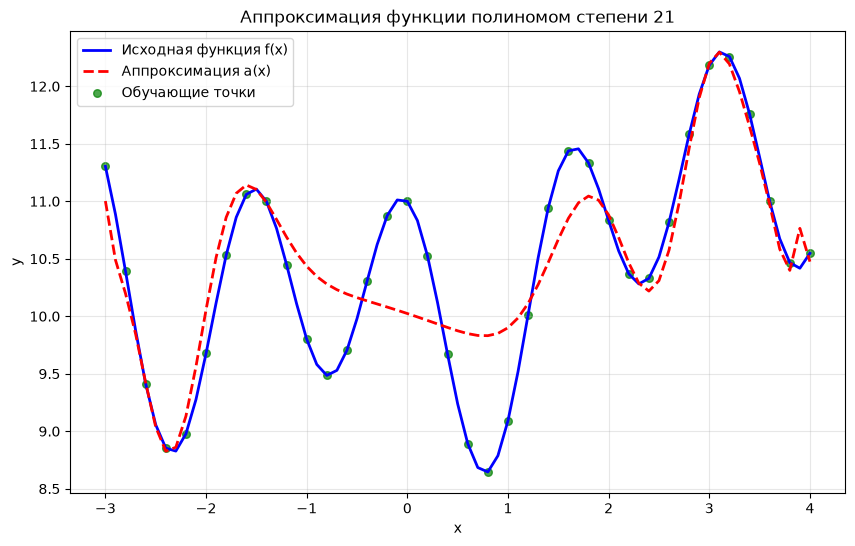

In [7]:
import numpy as np


def func(x):
    return 0.1 * x + 0.1 * x ** 2 - 0.5 * np.sin(2*x) + 1 * np.cos(4*x) + 10


x = np.arange(-3.0, 4.1, 0.1) # значения по оси абсцисс (Ox) с шагом 0,1
y = np.array(func(x)) # значения функции по оси ординат

N = 22  # размер признакового пространства (степень полинома N-1)
lm = 20  # параметр лямбда для L2-регуляризатора

X = np.array([[a ** n for n in range(N)] for a in x])  # матрица входных векторов
IL = lm * np.eye(N)  # матрица lambda*I
IL[0][0] = 0  # первый коэффициент не регуляризуем

X_train = X[::2]  # обучающая выборка (входы)
Y_train = y[::2]  # обучающая выборка (целевые значения)

# здесь продолжайте программу
w = np.linalg.inv(X_train.T @ X_train + IL) @ X_train.T @ Y_train

a = X @ w
Q = np.mean((a - y) ** 2)
print(f"w = {w}")
print(f"Q(a, X) = {Q}")

# Построение графиков
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', label='Исходная функция f(x)', linewidth=2)
plt.plot(x, a, 'r--', label='Аппроксимация a(x)', linewidth=2)
plt.scatter(x[::2], y[::2], color='green', s=30, label='Обучающие точки', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Аппроксимация функции полиномом степени {}'.format(N-1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Задача 2:
Дана функция:

$f(x)=0.5⋅x+0.2⋅x^2−0.05⋅x^3+0.2⋅sin(4x)−2.5$

Необходимо выполнить ее аппроксимацию (восстановление) на интервале [-4, 6] моделью вида:

$a(x)=w0+\sum_{i=1}^{N−1}w_i⋅x_i$ при N=5.

Вектор параметров $w=[w_0,w_1,⋯ ,w_{N−1}]^T$ следует искать с помощью алгоритма стохастического градиентного спуска (SGD) с L2-регуляризатором:

$w_n=w_{n−1}−η⋅(\frac{∂Qk(w)}{∂w}+λ⋅\tilde w)$

где $\tilde w=[0,w_1,⋯ ,w_{N−1}]T$ - вектор с исключенным первым параметром w0​; k - случайно выбранный образ из обучающей выборки; Qk(w) - усеченный эмпирический риск:

$Qk(w)=\frac{1}{K}\sum_{i=k}^{k+K−1}(a(x_i,w)−y_i)^2=1frac{1}{K}\sum_{i=k}^{k+K−1}(w^T⋅x_i−y_i)^2$

где $x_i=[1,x,x^2,⋯ ,x^{N−1}]T$ - вектор признаков i-го образа; yi​ - значение функции f(x) в i-й точке.

Производная усеченного показателя качества может быть записана в следующем векторно-матричном виде:

$\frac{∂Qk(w)}{∂w}=\frac{2}{K}\sum_{i=k}^{k+K−1}(w^T⋅x_i−y_i)⋅x_i^T$

То есть, псевдоградиент вычисляется не по одному образу k, а по образам в диапазоне [k; k+K) (всего K образов).

Продолжите программу, в которой объявлена функция f(x) с именем func, заданы значения функции по оси абсцисс и ординат, а также начальные значения и параметры для алгоритма SGD с L2-регуляризатором:
```python
import numpy as np

# исходная функция, которую нужно аппроксимировать моделью a(x)
def func(x):
    return 0.5 * x + 0.2 * x ** 2 - 0.05 * x ** 3 + 0.2 * np.sin(4 * x) - 2.5

# модель
def model(w, x):
    xv = np.array([x ** n for n in range(len(w))])
    return w.T @ xv

# функция потерь
def loss(w, x, y):
    return (model(w, x) - y) ** 2

# производная функции потерь
def dL(w, x, y):
    xv = np.array([x ** n for n in range(len(w))])
    return 2 * (model(w, x) - y) * xv


coord_x = np.arange(-4.0, 6.0, 0.1) # значения по оси абсцисс [-4; 6] с шагом 0.1
coord_y = func(coord_x) # значения функции по оси ординат

N = 5 # сложность модели (полином степени N-1)
lm_l2 = 2 # коэффициент лямбда для L2-регуляризатора
sz = len(coord_x)	# количество значений функций (точек)
eta = np.array([0.1, 0.01, 0.001, 0.0001, 0.000002]) # шаг обучения для каждого параметра w0, w1, w2, w3, w4
w = np.zeros(N) # начальные нулевые значения параметров модели
n_iter = 500 # число итераций алгоритма SGD
lm = 0.02 # значение параметра лямбда для вычисления скользящего экспоненциального среднего
batch_size = 20 # размер мини-батча (величина K = 20)

Qe = # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел
```

На каждой итерации алгоритма SGD необходимо выбирать начальное значение k командой:
```python
k = np.random.randint(0, sz-batch_size-1) # sz - размер выборки (массива coord_x)
```
и из массива coord_x формировать векторы признаков:

$x_i=[1,x,x^2,⋯ ,x^{N−1}]^T$

для вычисления псевдоградиента Qk по образам от k до k + batch_size (команда range(k, k+batch_size))

Также на каждой итерации нужно пересчитывать значение Qe экспоненциального скользящего среднего по формуле:

$Qe=λ⋅Qk(w)+(1−λ)⋅Qe$

Вычисленные параметры вектора ww следует сохранить в виде списка или кортежа с именем w. Также нужно вычислить итоговое значение среднего эмпирического риска для обученной модели по формуле:

$Q(a,X)=\frac{1}{n}⋅\sum_{i=1}^{n}(a(x_i,w)−y_i)^2$

Вычисленное значение Q(a,X) сохраните в переменной Q, а последнее значение Qe - в переменной Qe.

Домашнее задание: оцените как изменится качество аппроксимации без L2-регуляризатора; постройте графики исходной функции и результат ее восстановления моделью a(x)a(x) (для построения графиков используйте пакет matplotlib).

In [8]:
import numpy as np

# исходная функция, которую нужно аппроксимировать моделью a(x)
def func(x):
    return 0.5 * x + 0.2 * x ** 2 - 0.05 * x ** 3 + 0.2 * np.sin(4 * x) - 2.5


# модель
def model(w, x):
    xv = np.array([x ** n for n in range(len(w))])
    return w.T @ xv


# функция потерь
def loss(w, x, y):
    return (model(w, x) - y) ** 2


# производная функции потерь
def dL(w, x, y):
    xv = np.array([x ** n for n in range(len(w))])
    return 2 * (model(w, x) - y) * xv


coord_x = np.arange(-4.0, 6.0, 0.1) # значения по оси абсцисс [-4; 6] с шагом 0.1
coord_y = func(coord_x) # значения функции по оси ординат

N = 5 # сложность модели (полином степени N-1)
lm_l2 = 2 # коэффициент лямбда для L2-регуляризатора
sz = len(coord_x)	# количество значений функций (точек)
eta = np.array([0.1, 0.01, 0.001, 0.0001, 0.000002]) # шаг обучения для каждого параметра w0, w1, w2, w3, w4
w = np.zeros(N) # начальные нулевые значения параметров модели
n_iter = 500 # число итераций алгоритма SGD
lm = 0.02 # значение параметра лямбда для вычисления скользящего экспоненциального среднего
batch_size = 20 # размер мини-батча (величина K = 20)

Qe = 0.0 # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел

# здесь продолжайте программу
for i in range(n_iter): 
    k = np.random.randint(0, sz - batch_size - 1)

    grad = np.zeros(N)
    loss_sum = 0.0

    for j in range(k, k + batch_size):
        x = coord_x[j]
        y = coord_y[j]
        xv = np.array([x ** n for n in range(N)])

        grad += dL(w, x, y)
        loss_sum += loss(w, x, y)
    
    grad = grad / batch_size
    Qk = loss_sum / batch_size
    
    # L2-reg
    w_reg = np.copy(w)
    w_reg[0] = 0 # w_0 - исключаем
    grad += lm_l2 * w_reg

    w = w - eta * grad

    Qe = lm * Qk + (1 - lm) * Qe

a = np.array([model(w, x) for x in coord_x])
Q = np.mean((a - coord_y) ** 2)
print(f"w = {w}")
print(f"Q = {Q}")

w = [-2.43710903  0.16673647  0.19592597 -0.02461137 -0.00352843]
Q = 0.2892829896920532


Результаты:
С регуляризацией: Q = 0.289283
Без регуляризации: Q = 11.346867
Разница: 11.057584


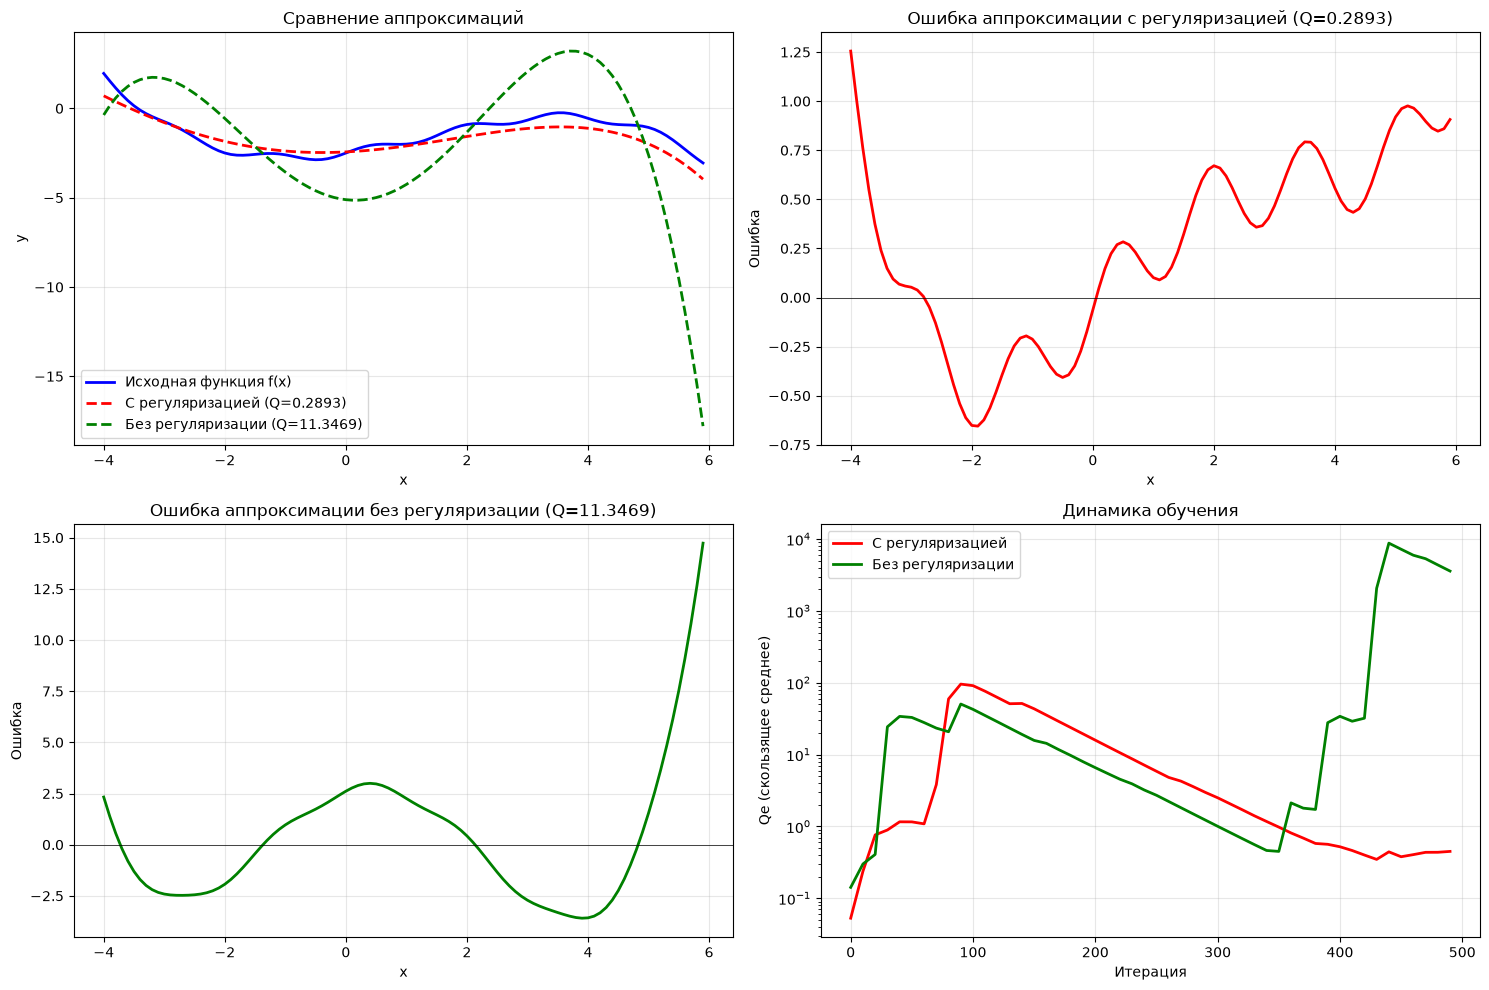


Коэффициенты модели:
Параметр | С регуляризацией | Без регуляризации
--------------------------------------------------
w 0     |       -2.437109 |       -5.112181
w 1     |        0.166736 |       -0.397064
w 2     |        0.195926 |        1.254354
w 3     |       -0.024611 |        0.051283
w 4     |       -0.003528 |       -0.053255


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Исходная функция
def func(x):
    return 0.5 * x + 0.2 * x ** 2 - 0.05 * x ** 3 + 0.2 * np.sin(4 * x) - 2.5

def model(w, x):
    xv = np.array([x ** n for n in range(len(w))])
    return w.T @ xv

# Данные
coord_x = np.arange(-4.0, 6.0, 0.1)
coord_y = func(coord_x)

N = 5
sz = len(coord_x)
batch_size = 20
n_iter = 500
lm = 0.02
np.random.seed(0)

# Функция обучения с регуляризацией или без
def train_with_regularization(use_reg=True, lm_l2=2.0):
    eta = np.array([0.1, 0.01, 0.001, 0.0001, 0.000002])
    w = np.zeros(N)
    Qe = 0.0
    history_w = []
    history_Qe = []
    
    for i in range(n_iter):
        k = np.random.randint(0, sz - batch_size - 1)
        grad = np.zeros(N)
        loss_sum = 0.0
        
        for j in range(k, k + batch_size):
            x = coord_x[j]
            y = coord_y[j]
            xv = np.array([x ** n for n in range(N)])
            grad += 2 * (model(w, x) - y) * xv
            loss_sum += (model(w, x) - y) ** 2
        
        grad = grad / batch_size
        
        if use_reg:
            w_reg = np.copy(w)
            w_reg[0] = 0
            grad += lm_l2 * w_reg
        
        w = w - eta * grad
        Qk = loss_sum / batch_size
        Qe = lm * Qk + (1 - lm) * Qe
        
        if i % 10 == 0:
            history_w.append(w.copy())
            history_Qe.append(Qe)
    
    # Вычисляем итоговую ошибку
    a = np.array([model(w, x) for x in coord_x])
    Q = np.mean((a - coord_y) ** 2)
    
    return w, Q, a, history_Qe

# Обучение с регуляризацией
w_reg, Q_reg, a_reg, history_reg = train_with_regularization(use_reg=True, lm_l2=2.0)

# Обучение без регуляризации
w_no_reg, Q_no_reg, a_no_reg, history_no_reg = train_with_regularization(use_reg=False, lm_l2=0.0)

print("Результаты:")
print(f"С регуляризацией: Q = {Q_reg:.6f}")
print(f"Без регуляризации: Q = {Q_no_reg:.6f}")
print(f"Разница: {Q_no_reg - Q_reg:.6f}")

# Построение графиков
plt.figure(figsize=(15, 10))

# График 1: Исходная функция и аппроксимации
plt.subplot(2, 2, 1)
plt.plot(coord_x, coord_y, 'b-', label='Исходная функция f(x)', linewidth=2)
plt.plot(coord_x, a_reg, 'r--', label=f'С регуляризацией (Q={Q_reg:.4f})', linewidth=2)
plt.plot(coord_x, a_no_reg, 'g--', label=f'Без регуляризации (Q={Q_no_reg:.4f})', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение аппроксимаций')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Ошибка аппроксимации с регуляризацией
plt.subplot(2, 2, 2)
plt.plot(coord_x, coord_y - a_reg, 'r-', linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('Ошибка')
plt.title(f'Ошибка аппроксимации с регуляризацией (Q={Q_reg:.4f})')
plt.grid(True, alpha=0.3)

# График 3: Ошибка аппроксимации без регуляризации
plt.subplot(2, 2, 3)
plt.plot(coord_x, coord_y - a_no_reg, 'g-', linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('Ошибка')
plt.title(f'Ошибка аппроксимации без регуляризации (Q={Q_no_reg:.4f})')
plt.grid(True, alpha=0.3)

# График 4: Динамика обучения (скользящее среднее)
plt.subplot(2, 2, 4)
plt.plot(range(0, n_iter, 10), history_reg, 'r-', label='С регуляризацией', linewidth=2)
plt.plot(range(0, n_iter, 10), history_no_reg, 'g-', label='Без регуляризации', linewidth=2)
plt.xlabel('Итерация')
plt.ylabel('Qe (скользящее среднее)')
plt.title('Динамика обучения')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ коэффициентов
print("\nКоэффициенты модели:")
print("Параметр | С регуляризацией | Без регуляризации")
print("-" * 50)
for i in range(N):
    print(f"w{i:2d}     | {w_reg[i]:15.6f} | {w_no_reg[i]:15.6f}")